# Practical 09: Denoising & Dimensionality Reduction using Autoencoders

In [2]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.2 MB/s eta 0:00:00


In [6]:
# ============================================================
# MEDICAL MNIST DENOISING + DIMENSIONALITY REDUCTION
# U-NET AUTOENCODER + SSIM LOSS (IMPROVED VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

import medmnist
from medmnist import INFO

In [ ]:
# ============================================================
# LOAD MEDMNIST DATASET
# ============================================================

data_flag = "pathmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

train = DataClass(split="train", download=True)
test = DataClass(split="test", download=True)

x_train = train.imgs.astype("float32") / 255.0
x_test = test.imgs.astype("float32") / 255.0

y_train = train.labels
y_test = test.labels

# Convert RGB → grayscale (optional but helps stability)
if x_train.shape[-1] == 3:
    x_train = np.mean(x_train, axis=-1, keepdims=True)
    x_test = np.mean(x_test, axis=-1, keepdims=True)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

In [7]:
# ============================================================
# ADD NOISE (controlled for medical realism)
# ============================================================

noise_factor = 0.2

x_train_noisy = np.clip(
    x_train + noise_factor * np.random.normal(size=x_train.shape),
    0., 1.
)

x_test_noisy = np.clip(
    x_test + noise_factor * np.random.normal(size=x_test.shape),
    0., 1.
)

In [8]:
# ============================================================
# U-NET STYLE AUTOENCODER
# ============================================================

input_img = Input(shape=(28, 28, 1))

# ---------------- ENCODER ----------------
c1 = Conv2D(64, 3, padding="same", activation="relu")(input_img)
c1 = BatchNormalization()(c1)
c1 = Conv2D(64, 3, padding="same", activation="relu")(c1)
p1 = MaxPooling2D()(c1)

c2 = Conv2D(128, 3, padding="same", activation="relu")(p1)
c2 = BatchNormalization()(c2)
c2 = Conv2D(128, 3, padding="same", activation="relu")(c2)
p2 = MaxPooling2D()(c2)

# ---------------- BOTTLENECK (LATENT SPACE) ----------------
b = Conv2D(256, 3, padding="same", activation="relu", name="latent")(p2)
b = BatchNormalization()(b)

# ---------------- DECODER ----------------
u1 = UpSampling2D()(b)
u1 = Concatenate()([u1, c2])
c3 = Conv2D(128, 3, padding="same", activation="relu")(u1)
c3 = BatchNormalization()(c3)

u2 = UpSampling2D()(c3)
u2 = Concatenate()([u2, c1])
c4 = Conv2D(64, 3, padding="same", activation="relu")(u2)
c4 = BatchNormalization()(c4)

output = Conv2D(1, 1, activation="sigmoid")(c4)

model = Model(input_img, output)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 28, 28,    │        640 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 28, 28,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 14, 14,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 14, 14,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 7, 7, 128) │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Conv2D)     │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ latent[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 14, 14,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 384)              │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 14, 14,    │    442,496 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 28, 28,    │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 192)              │            │ conv2d_22[0][0] 

 Total params: 1,109,953 (4.23 MB)

 Trainable params: 1,108,673 (4.23 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [9]:
# ============================================================
# SSIM + MSE COMBINED LOSS (IMPORTANT IMPROVEMENT)
# ============================================================

def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mse + 0.5 * ssim_loss(y_true, y_pred)

In [10]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=combined_loss
)

# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=10,          # increase for better quality
    batch_size=128,
    shuffle=True
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - loss: 0.2258 - val_loss: 0.2108
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - loss: 0.2168 - val_loss: 0.2132
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - loss: 0.2152 - val_loss: 0.1983
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - loss: 0.2142 - val_loss: 0.2128
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - loss: 0.2136 - val_loss: 0.2042
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - loss: 0.2129 - val_loss: 0.2002
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - loss: 0.2125 - val_loss: 0.1972
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - loss: 0.2120 - val_loss: 0.2050
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - loss: 0.2114 - val_loss: 0.2081
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - loss: 0.2113 - val_loss: 0.2073


In [11]:
# ============================================================
# DENOISING PREDICTION
# ============================================================

x_pred = model.predict(x_test_noisy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


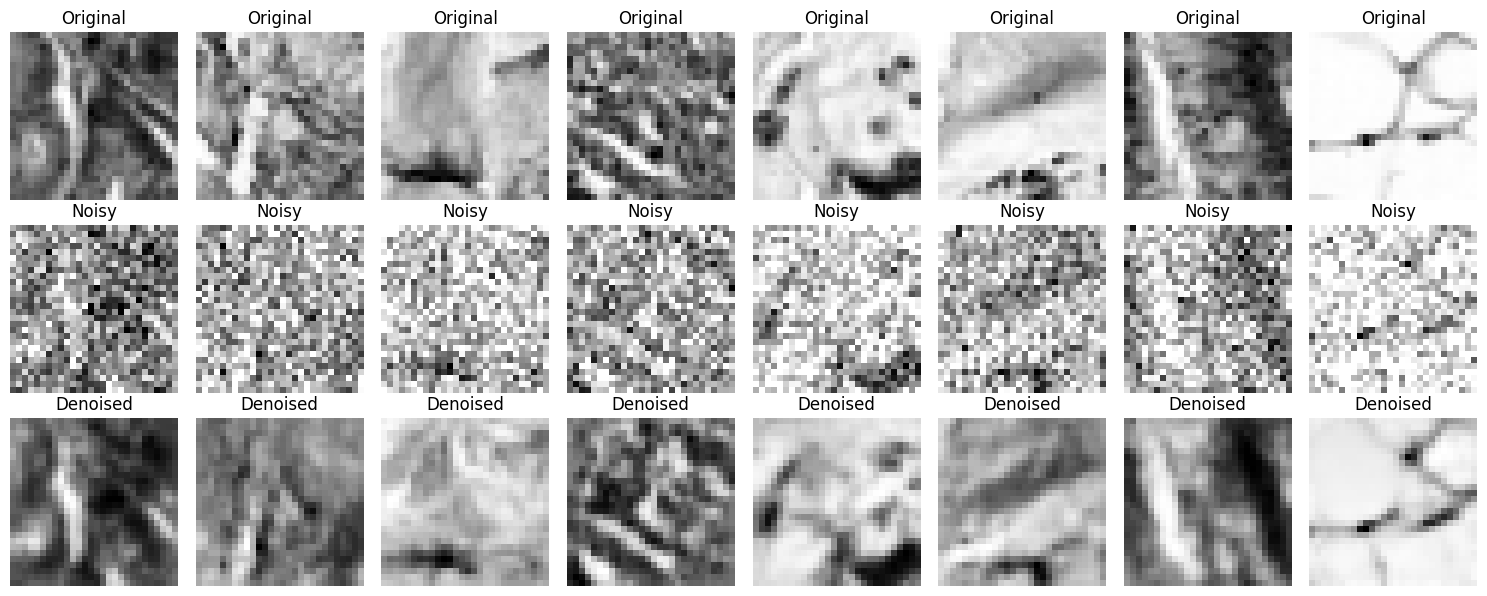

In [12]:
# ============================================================
# VISUALIZATION: ORIGINAL vs NOISY vs DENOISED
# ============================================================

n = 8
plt.figure(figsize=(15, 6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_pred[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

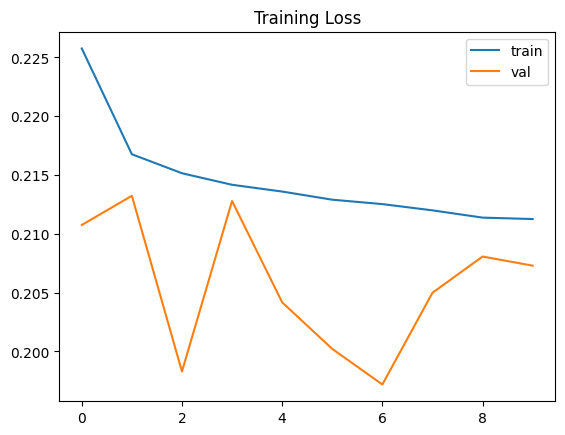

In [13]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Training Loss")
plt.legend()
plt.show()

In [14]:
# ============================================================
# LATENT SPACE EXTRACTION (DIMENSIONALITY REDUCTION)
# ============================================================

encoder = Model(model.input, model.get_layer("latent").output)

latent = encoder.predict(x_test)
latent_flat = latent.reshape(latent.shape[0], -1)

print("Latent shape:", latent_flat.shape)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Latent shape: (7180, 12544)


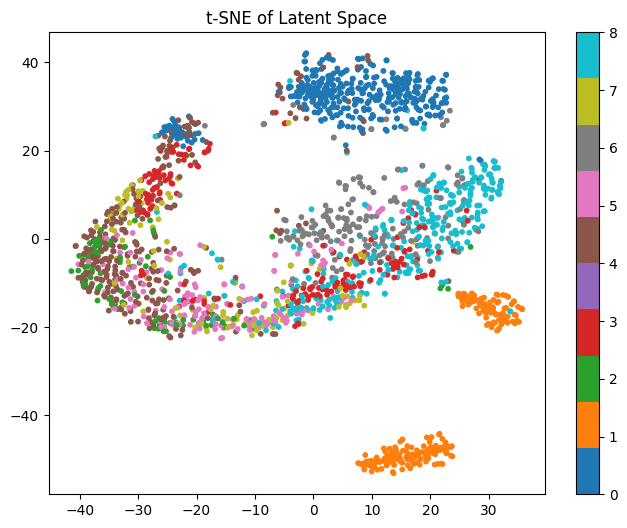

In [15]:
# ============================================================
# t-SNE VISUALIZATION
# ============================================================

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

latent_2d = tsne.fit_transform(latent_flat[:2000])
labels = y_test[:2000].flatten()

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="tab10", s=10)
plt.colorbar()
plt.title("t-SNE of Latent Space")
plt.show()

In [16]:
# ============================================================
# METRICS (MSE)
# ============================================================

mse = mean_squared_error(x_test.flatten(), x_pred.flatten())

print("\n==============================")
print("MSE:", mse)
print("==============================")


MSE: 0.004865647759288549
